In [ ]:
##Figure6A

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

def plot_box_by_group_and_label(df_plot: pd.DataFrame, score_col: str, out_dir: str):
    os.makedirs(out_dir, exist_ok=True)

    df_plot["label_group"] = df_plot["label"].map({1: "target", 0: "decoy"})
    df_plot = df_plot[df_plot["label_group"].notna()].copy()

    if len(df_plot) == 0:
        print("No rows with label in {0,1} for boxplot; skip plotting.")
        return

    #df_plot.to_csv(os.path.join(out_dir, "df_plot.csv"), index=False)
    order = ["train", "holdout"]
    df_plot["pep_group"] = pd.Categorical(df_plot["pep_group"], categories=order, ordered=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

    for ax, label_group in zip(axes, ["target", "decoy"]):
        sub = df_plot[df_plot["label_group"] == label_group].copy()
        if sub.empty:
            ax.set_title(label_group)
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue

        sns.boxplot(
            data=sub,
            x="pep_group",
            y=score_col,
            order=order,
            showfliers=False,
            ax=ax,
        )

        ax.set_title(label_group)
        ax.set_xlabel("")
        ax.set_ylabel(score_col)

    plt.tight_layout()

    base_name = "score_box_train_holdout"
    out_pdf = os.path.join(out_dir, f"{base_name}.pdf")
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved boxplot to {out_pdf}")


def load_df_from_csv(file_path: str) -> pd.DataFrame:
    df = pd.read_csv(file_path)
    print(f"Loaded data from {file_path}")
    return df


def main():
    input_csv_path = "/ajun/DDA_BERT_manu/manu_pep_score_plot/dataset118_2_pep_chunk/df_plot.csv"
    output_dir = "/ajun/DDA_BERT_manu/manu_pep_score_plot"
    df_plot = load_df_from_csv(input_csv_path)
    plot_box_by_group_and_label(df_plot, "score", output_dir)

if __name__ == "__main__":
    main()

Loaded data from /ajun/DDA_BERT_manu/manu_pep_score_plot/dataset118_2_pep_chunk/df_plot.csv
Saved boxplot to /ajun/DDA_BERT_manu/manu_pep_score_plot/test/score_box_train_holdout.pdf


In [ ]:
##Figure6B

Saved: /ajun/DDA_BERT_manu/dataset118_1_pep_chunk/human_intensity.pdf


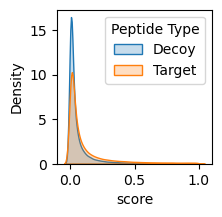

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

input_csv = "/ajun/DDA_BERT_manu/dataset118_1_pep_chunk/input.csv"
df_all = pd.read_csv(input_csv)

df_all["file_name"] = df_all["file_name"].astype(str)
df_all["scan_number"] = pd.to_numeric(df_all["scan_number"], errors="coerce")
df_all["score"] = pd.to_numeric(df_all["score"], errors="coerce")
df_all = df_all.dropna(subset=["file_name", "scan_number", "score"]).copy()

df_all = df_all.sort_values(
    ["file_name", "scan_number", "score"],
    ascending=[True, True, False],
    kind="mergesort",
)

df_all = df_all.drop_duplicates(subset=["file_name", "scan_number"], keep="first").reset_index(drop=True)

plt.figure(figsize=(2, 2))

sns.kdeplot(data=df_all[df_all["label"] == 0], x="score", label="Decoy", fill=True)
sns.kdeplot(data=df_all[df_all["label"] == 1], x="score", label="Target", fill=True)

plt.xlabel("score")
plt.ylabel("Density")
plt.legend(title="Peptide Type", loc="best")

out_path = "/ajun/DDA_BERT_manu/dataset118_1_pep_chunk/human_intensity.pdf"
plt.savefig(out_path, format="pdf", bbox_inches="tight")
print(f"Saved: {out_path}")

plt.show()
plt.close()
